# 24.3) Configuração do ambiente aprendizagem por reforço com Q-Learning

Ambiente maq2 no anconda 2, no linux

# Aprendizagem por Reforço com Q-Learning

- Código adaptado de: https://www.learndatasci.com/tutorials/reinforcement-q-learning-scratch-python-openai-gym/

In [1]:
#!pip install gym # primeiro passo, está na versão 0.26.2

In [2]:
#!pip uninstall gym

(base) :~$ conda env list

(base) :~$ conda activate Maq2

(Maq2) : pip uninstall gym

Found existing installation: gym 0.26.2


In [3]:
#!pip install gym==0.17.3 # Use esta versão para conseguir visualizar o ambiente

## Entendimento do ambiente

In [4]:
import gym
import random
import os
#os.environ["SDL_VIDEODRIVER"] = "dummy"
gym.__version__

'0.17.3'

In [5]:
env = gym.make('Taxi-v3')

In [6]:
env.reset()
env.render()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



In [7]:
env.render() # local para buscar o taxi

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




Amarelo está vazio o táxi, 

cor verde com passageiro, 

A letra azul onde o passageiro sai de forma inicial, 

e a letra rosa  onde o passageiro tem que chegar. 


A | barreira são os obstáculos , o carro não pode cruzar as barreiras.

In [8]:
env.reset() # resetar e 
env.render() # renderizar novamente, colocando em posições diferentes

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+



In [9]:
# espaço de ações

# 6 posições que o agente pode fazer, ações de movimento:
# 0 = south 1 = north 2 = east 3 = west 4 = pickup 5 = dropoff
# pickup- pegar , e dropoff- deixar o passageiro
# pegar e deixar o passageiro:

print(env.action_space)

Discrete(6)


gym.openai.com/envs/Taxi-v3

https://gymnasium.farama.org/

https://www.gymlibrary.dev/environments/toy_text/taxi/#observations

In [10]:
# se pode ter 500 movimentos, pois há 4 destinos, com uma matriz de 5 linhas, e 5 colunas
print(env.observation_space)

Discrete(500)


In [11]:
#5*5*5*4 -- Atualizado 22/11/2022 ref. https://www.gymlibrary.dev/environments/toy_text/taxi/#observations
25*5*4

500

In [12]:
#5*linhas*colunas*possíveis posições do passageiro = total de condição de estados do ambiente 500

In [13]:
# quanto maior a matriz maior o número de estados;

In [14]:
# P variáveis de estados possíveis
len(env.P)

500

In [15]:
#env.P # mostrar todos os estados possíveis, em dicionário

In [16]:
env.P[0]

{0: [(1.0, 100, -1, False)],
 1: [(1.0, 0, -1, False)],
 2: [(1.0, 20, -1, False)],
 3: [(1.0, 0, -1, False)],
 4: [(1.0, 16, -1, False)],
 5: [(1.0, 0, -10, False)]}

In [17]:
env.P[484] # uma dessas ações

{0: [(1.0, 484, -1, False)],
 1: [(1.0, 384, -1, False)],
 2: [(1.0, 484, -1, False)],
 3: [(1.0, 464, -1, False)],
 4: [(1.0, 484, -10, False)],
 5: [(1.0, 484, -10, False)]}

In [18]:
# [(probabilidade), (próximo estado), (recompensa), (indica se o jogo terminou ou não)]
# probabilidade 1.0 sempre 100%
# neste exemplo é um processo determinístico

#### a cada movimento há uma penalidade, no caso -1

isso é para incentivar o caminho mais rápido.

In [19]:
# penalidade maior com -10, quando deixa a pessoa no local errado. 

#### algoritmo tem que aprender no decorer do tempo a fazer ssas melhores rotas




#### A) Aprendizagem por reforço

existem um ambiente para chegar na posição

existe um agente que interage ao ambiente. 


estados são as posições que o agente ocupa no ambiente.

o agente recebe recompensa positiva ou negativa. Se aproxima do objetivo apresenta uma recompensa positiva, caso se afaste do objetivo recebe a recompensa negativa. 


Isso tudo seria como se fosse um treinamento de um cachorro. 

Objetivo do táxi, exemplo:

pontos de busca e entrega dos passageiros, Y, R, G e B


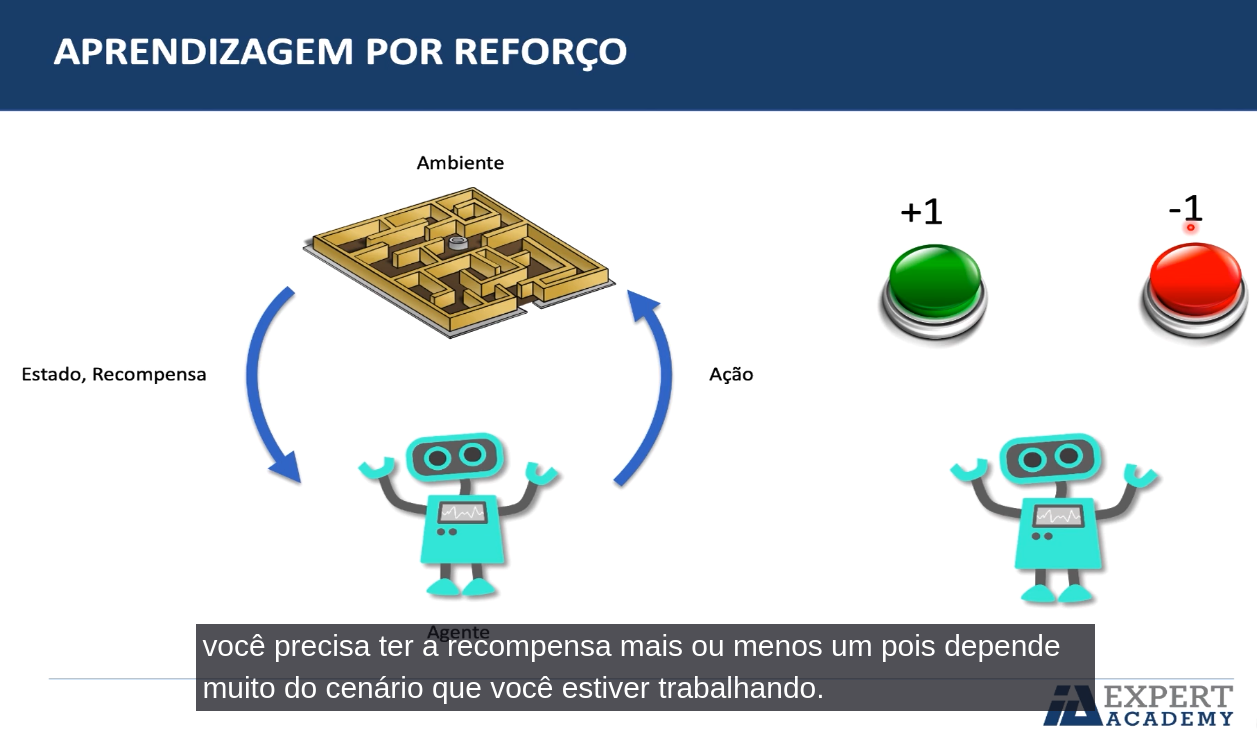

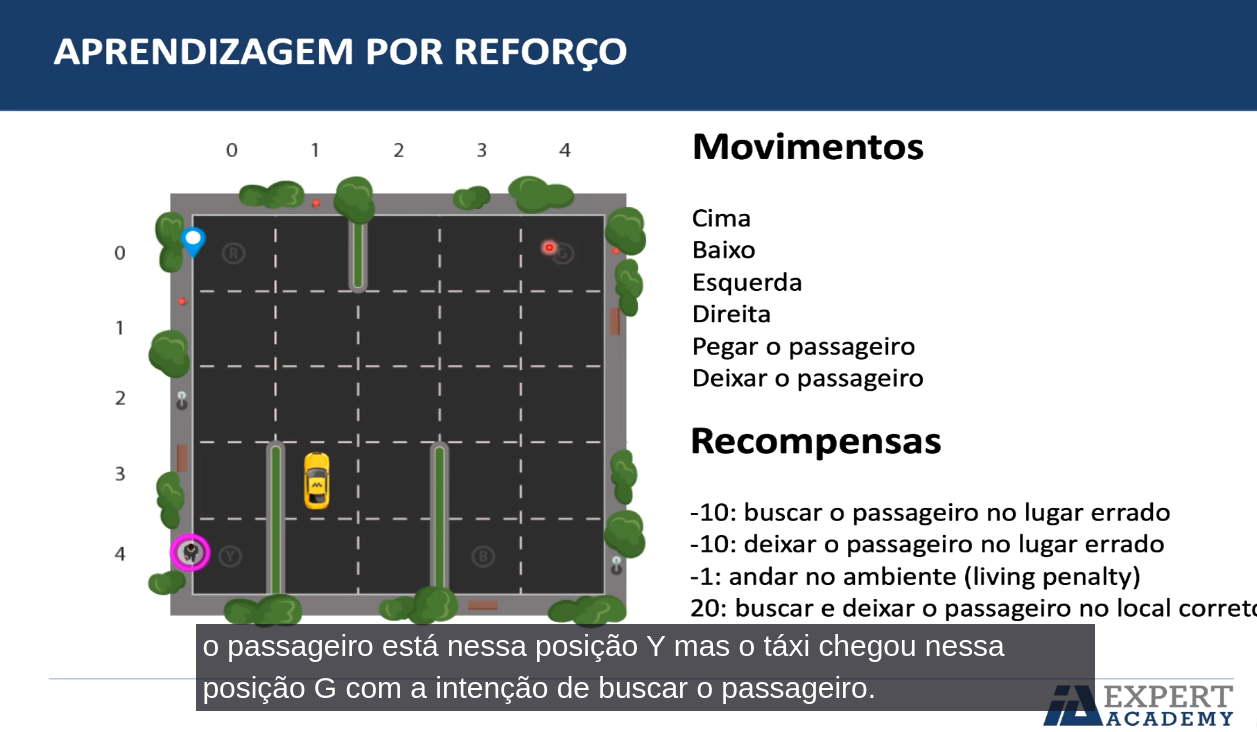


Algoritmo, o objetivo é começar do zero:


### -1 caminhar livin penalty, a ideia é fazer o menor movimento possível, ou seja a menor rota possível para não perder os pontos. 





## B) Equação Bellman

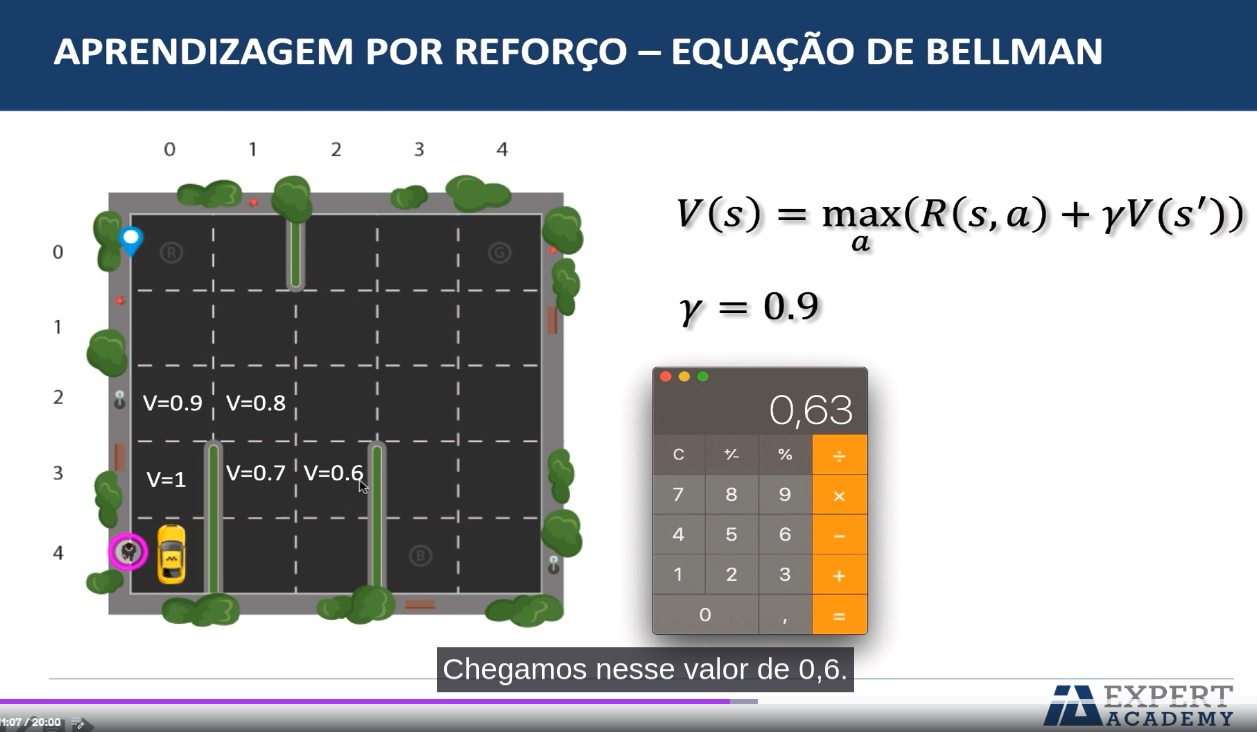

equação de bellman:

cada quadro tem um valor V, estado

R(s,a) => recompensa, com a determinada ação.

gama = 0,9 fator de desconto, definido no algoritmo.

V(s') = de cada estado:


v=1 melhor estado, 

v=0,9 menor, valor distante do objetivo
0,9*0,9=0,81

v=0,8 menor, valor distante do objetivo
0,9*0,8 = 0,72

v=0,7 menor, valor distante do objetivo
0,9*0,7=0,63

### O agente vai seguir os caminhos com os maiores valores. 

### Aprendizagem por reforço -> Markov Decision Process (MDP)



exemplo, agente que já pegou o passageiro para levar no destino:
com o valor de v maior.



### Lado esquerdo (Agente segue para o melhor caminho exploitation): ambiente determinístico, com 100% de chance quando nós estamos nesta parte da estrada vamos no 100%. 

### lado direito (exploration): Ambiente não determinístico.

Não determinístico, com 90% de chance de estar acima e 10% ao lado, por isso usamos o MDP, markov decision process.

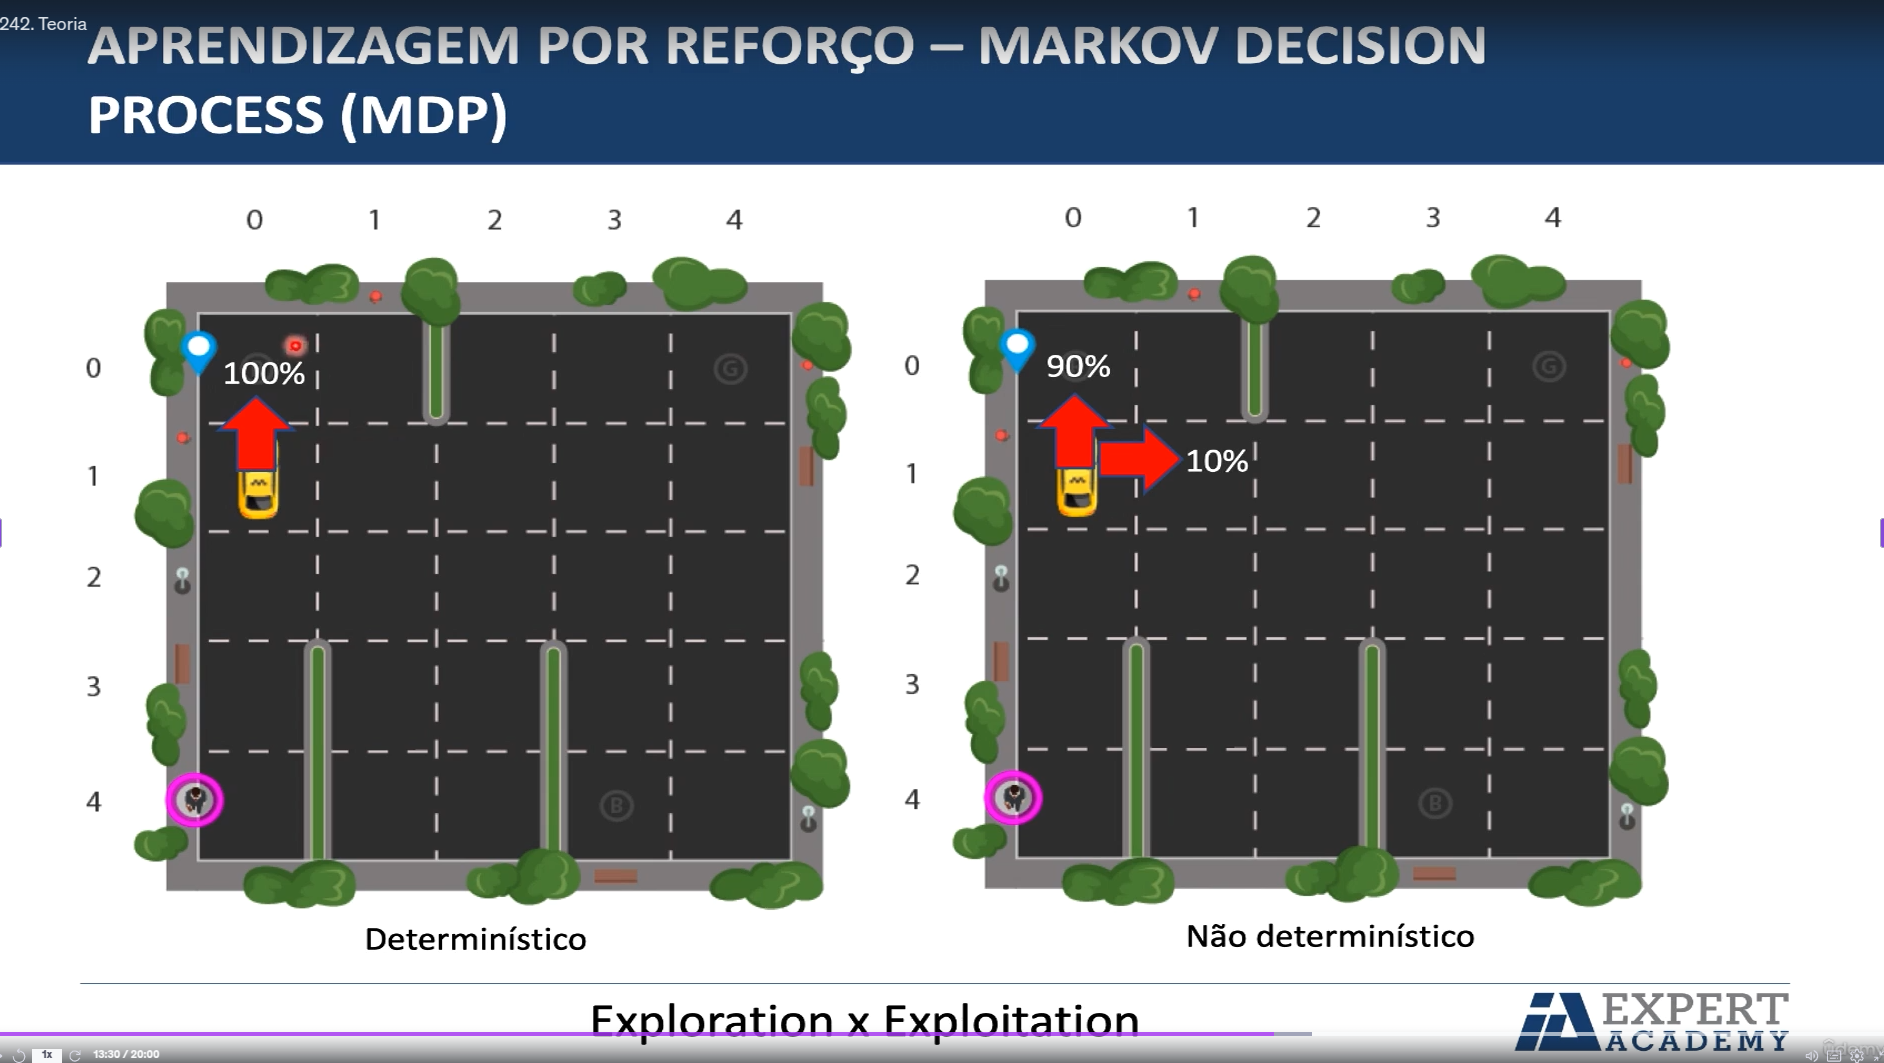

<p> Agente segue para o melhor caminho  <strong style="color:red;"> exploitation; </strong> </p>


<p>  <strong style="color:red;"> exploration:</strong>  probabilidade maior para seguir para o melhor caminho, mas a probabilidade menor para o outro caminho. Agente tem que explorar o ambiente.  </p>



último algoritmo chamado de Q-Learning. Base, fórmula matemática para escolher o melhor caminho, com 3 possibilidades.  

V(s) equação de Bellman, que o agente segue para o maior valor


estado S0= estado atual, ação a1, valor de Q, buscamos os valores de Q maior, e melhor é a solução. 


estado S0= estado atual, ação a2,

estado S0= estado atual, ação a3,


O Q na real é a qualidade da ação. 

### Q-learning, cálculo com base nas recompensas
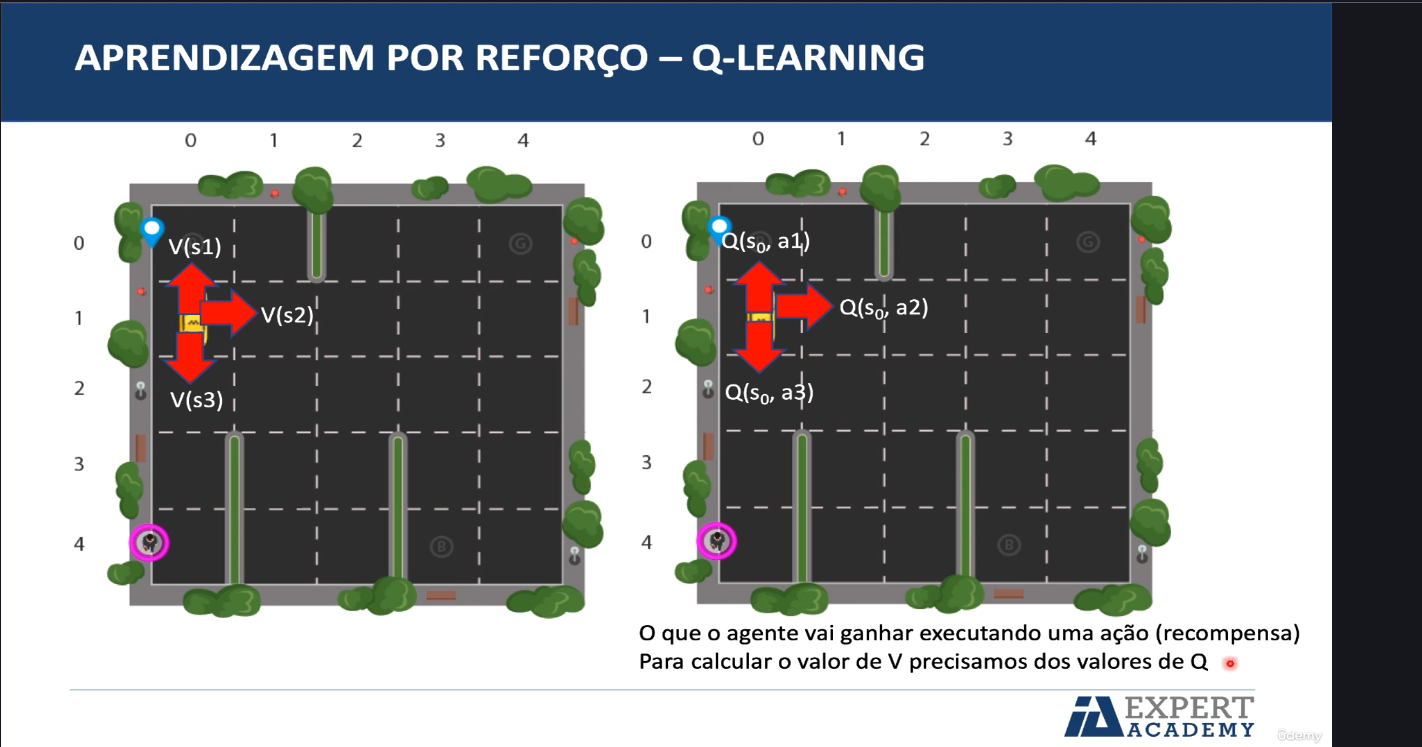

Temos a diferença temporal:

Aprendizagem por reforço => Diferença temporal

cálculo do vs

reforço, faz várias vezes a aprendizagem.


#### Qt-1 valor de Q anterior, mais a soma alfa (taxa de aprendizagem, quão rápido o algoritmo aprende)*recompensa  + gama desconto * estado

considerar o 0,9, por exemplo nas próximas rodadas

Nos exercícios implementaremos: Qt(s,a)

### que indicam os valores que colocaremos em cada matriz. 


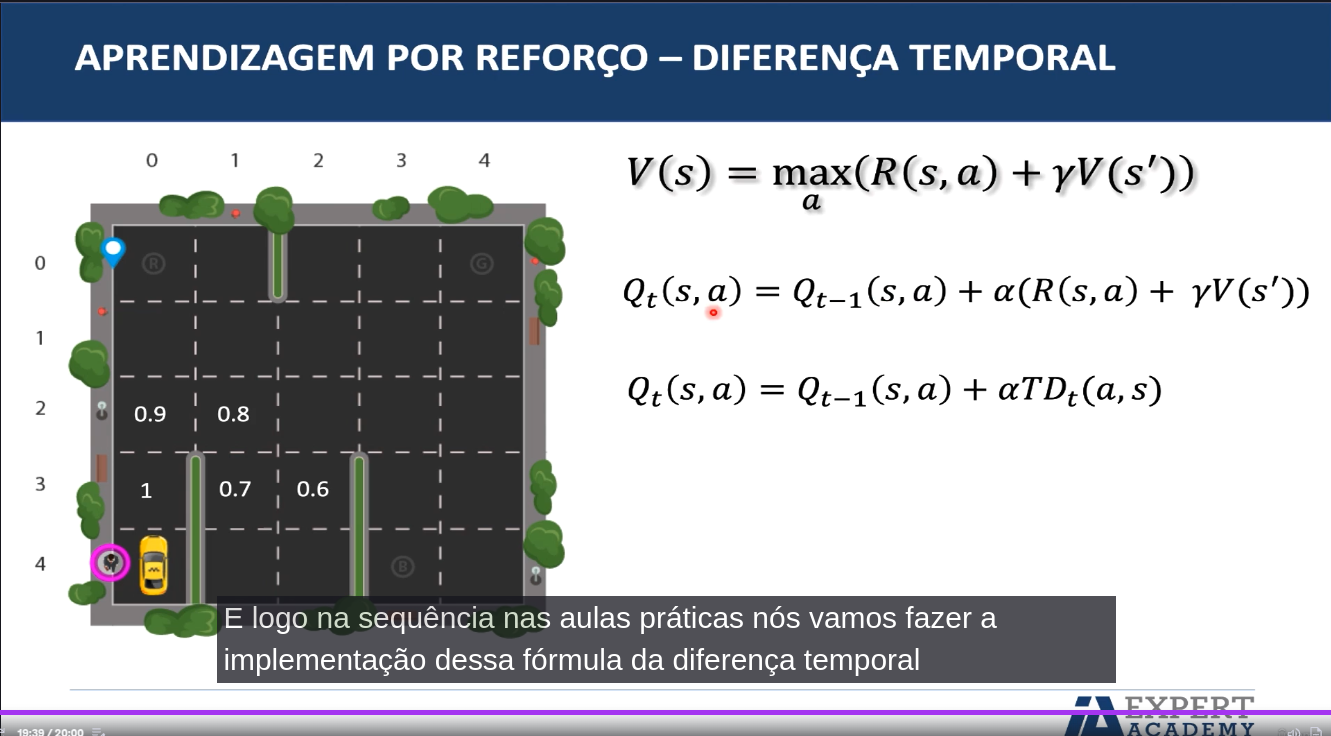